In [1]:
import pandas as pd
import numpy as np
import datetime as datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import math

In [3]:
import datetime

In [4]:
from scipy.signal import butter, filtfilt

In [5]:
import kneed
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# Open Sound Files

In [6]:
file_name = '../sound_proj/data/Raw-data/VTBS-SuvarnphumiAirport/2016/Leq0.5sec-VTBS-Date2MARto6MAR2016 ...xlsx'

In [7]:
xl = pd.ExcelFile(file_name)
sheet_list = xl.sheet_names
# sheet_list.remove("Billing")

In [8]:
sheet_list

['3-2-2016', '3-3-2016', '3-4-2016', '3-5-2016', '3-6-2016', 'Billing']

In [9]:
for c in ['Billing', 'billing']:
	if c in sheet_list:
		sheet_list.remove(c)

In [10]:
sound_files = [pd.read_excel(file_name, header=None, sheet_name=sn) for sn in sheet_list]

In [11]:
config_files = [dict(zip(sf[0:8][0], sf[0:8][1])) for sf in sound_files]

In [12]:
config_files[0]

{'File': '20160229_142826_000000_1.CMG',
 'Periods': '500ms',
 'Start': '3/2/2016 12:00:00 AM:000',
 'End': '3/3/2016 12:00:00 AM:000',
 'Location': 'Monsini-DUO #10130',
 'Weighting': 'A',
 'Data type': 'Slow',
 'Unit': 'dB'}

In [13]:
sound_files = [pd.concat([sf,pd.DataFrame({0:[config_files[i]['End']],1:[np.nan]})], ignore_index = True) for i, sf in enumerate(sound_files)]

In [14]:
data_list = [pd.DataFrame(sf[9:].values, columns=sf[8:9].values[0]) for sf in sound_files]

In [15]:
df = pd.concat(data_list)
df = df[~(df['Period start'].str.contains("Overall"))].reset_index(drop=True)
df

,Period start,Leq
0,3/2/2016 12:00:00 AM:000,47.9
1,3/2/2016 12:00:00 AM:500,47.5
2,3/2/2016 12:00:01 AM:000,47.5
3,3/2/2016 12:00:01 AM:500,47.6
4,3/2/2016 12:00:02 AM:000,47.7
...,...,...
864000,3/6/2016 11:59:58 PM:000,47.2
864001,3/6/2016 11:59:58 PM:500,46.9
864002,3/6/2016 11:59:59 PM:000,46.8
864003,3/6/2016 11:59:59 PM:500,47.8


In [31]:
def parse_date(dt):
	date_format = ['%m/%d/%Y %I:%M:%S %p:%f', '%Y/%m/%d %H:%M:%S', '%m/%d/%Y %H:%M:%S', '%Y/%m/%d %H:%M:%S',
	        	   '%Y-%m-%d', '%m-%d-%Y', '%d-%m-%Y', '%Y/%m/%d', '%m/%d/%Y', '%d/%m/%Y',
				   '%Y-%m-%d %H:%M:%S', '%m-%d-%Y %H:%M:%S', '%d-%m-%Y %H:%M:%S',
				   '%Y/%m/%d %H:%M:%S', '%m/%d/%Y %H:%M:%S', '%d/%m/%Y %H:%M:%S']

	for date_f in date_format:
		try:
			dateObject = datetime.datetime.strptime(dt, date_f)
			break
		except:
			dateObject = None
	
	return dateObject

In [32]:
print(parse_date('3/7/2016 12:00:00 AM:500'))

2016-03-07 00:00:00.500000


In [46]:
df['Period start'].apply(lambda a: parse_date(a))

0         None
1         None
2         None
3         None
4         None
          ... 
864000    None
864001    None
864002    None
864003    None
864004    None
Name: Period start, Length: 864005, dtype: object

In [18]:
df['Period start'] = df['Period start'].apply(lambda a: parse_date(a))

In [19]:
df_clean = df.copy()

In [20]:
df_clean.fillna(method='ffill', inplace=True)
df_clean

,Period start,Leq
0,2016-03-02 00:00:00.000,47.9
1,2016-03-02 00:00:00.500,47.5
2,2016-03-02 00:00:01.000,47.5
3,2016-03-02 00:00:01.500,47.6
4,2016-03-02 00:00:02.000,47.7
...,...,...
864000,2016-03-06 23:59:58.000,47.2
864001,2016-03-06 23:59:58.500,46.9
864002,2016-03-06 23:59:59.000,46.8
864003,2016-03-06 23:59:59.500,47.8


1 hr = 36000
1 hr = 60 min

In [21]:
one_hr_pts = 36000

pts_period = ((df_clean.iloc[1]['Period start'] - df_clean.iloc[0]['Period start']) / np.timedelta64(1, 's')) * 10
one_hr_result = int(one_hr_pts / pts_period)

n_pts_dict = {"half_day":one_hr_result * 12, "day":one_hr_result * 24, "week":one_hr_result * 24 * 7}

In [22]:
df_clean = df_clean.copy()
df_clean = df_clean[:n_pts_dict['week']]

# Event Detection

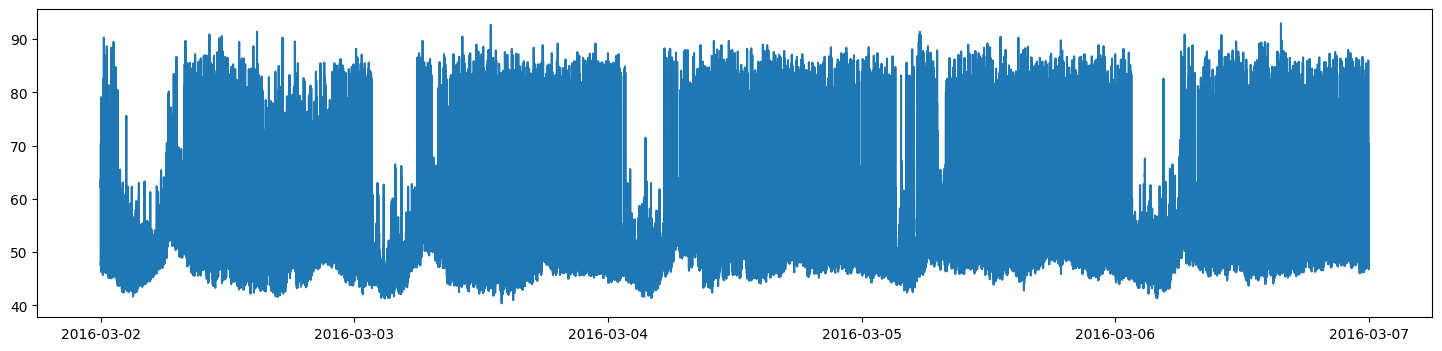

In [23]:
plt.figure(figsize=(18,4))
plt.plot(df_clean['Period start'], df_clean['Leq'])
plt.show()

## Preprocessing

### Filter using Cut-off

In [24]:
def cutoff(r, data):
    r = (100 - r) / 1000
    b, a = butter(4, r)
    filtered = filtfilt(b, a, data)
    return filtered

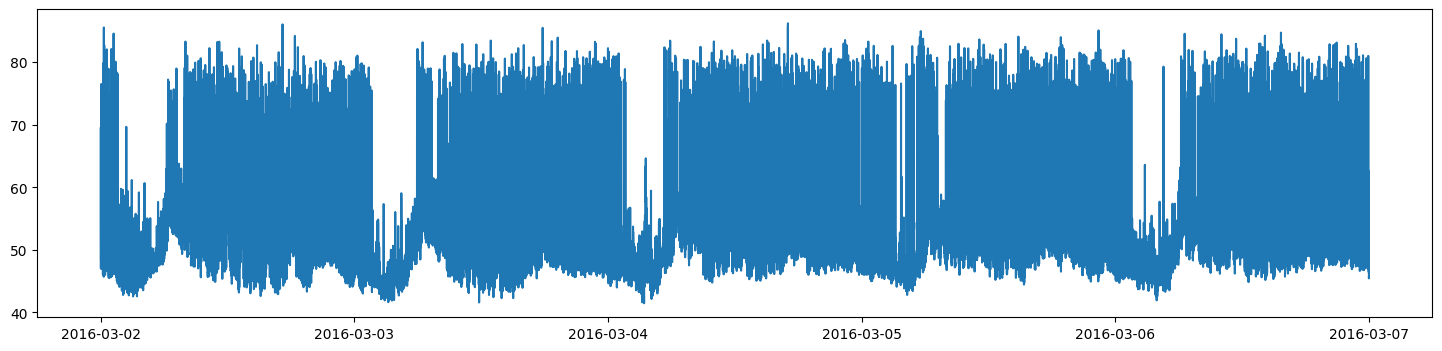

In [25]:
rate = 70
if(rate < 100):
    df_clean['Leq_filtered'] = cutoff(rate, df_clean['Leq'])

    plt.figure(figsize=(18,4))
    plt.plot(df_clean['Period start'], df_clean['Leq_filtered'])
    plt.show()
else:
    print("Error")

In [26]:
df_clean['Period start'].min(), df_clean['Period start'].max()

(Timestamp('2016-03-02 00:00:00'), Timestamp('2016-03-07 00:00:00'))

In [27]:
df_clean

,Period start,Leq,Leq_filtered
0,2016-03-02 00:00:00.000,47.9,47.176917
1,2016-03-02 00:00:00.500,47.5,47.437145
2,2016-03-02 00:00:01.000,47.5,47.707476
3,2016-03-02 00:00:01.500,47.6,47.988073
4,2016-03-02 00:00:02.000,47.7,48.279089
...,...,...,...
864000,2016-03-06 23:59:58.000,47.2,45.636562
864001,2016-03-06 23:59:58.500,46.9,45.651567
864002,2016-03-06 23:59:59.000,46.8,45.664967
864003,2016-03-06 23:59:59.500,47.8,45.676710


### Standardization

In [28]:
df_copy = df_clean.copy()

In [29]:
test2 = np.array(df_copy['Leq_filtered'])
test2 = test2.reshape(-1,1)

In [30]:
scaler = StandardScaler()
test2_normalized = scaler.fit_transform(test2)

In [31]:
df_copy['Leq_norm'] = test2_normalized

In [32]:
df_copy

,Period start,Leq,Leq_filtered,Leq_norm
0,2016-03-02 00:00:00.000,47.9,47.176917,-0.763220
1,2016-03-02 00:00:00.500,47.5,47.437145,-0.731462
2,2016-03-02 00:00:01.000,47.5,47.707476,-0.698471
3,2016-03-02 00:00:01.500,47.6,47.988073,-0.664227
4,2016-03-02 00:00:02.000,47.7,48.279089,-0.628711
...,...,...,...,...
864000,2016-03-06 23:59:58.000,47.2,45.636562,-0.951204
864001,2016-03-06 23:59:58.500,46.9,45.651567,-0.949373
864002,2016-03-06 23:59:59.000,46.8,45.664967,-0.947738
864003,2016-03-06 23:59:59.500,47.8,45.676710,-0.946305


## Clustering

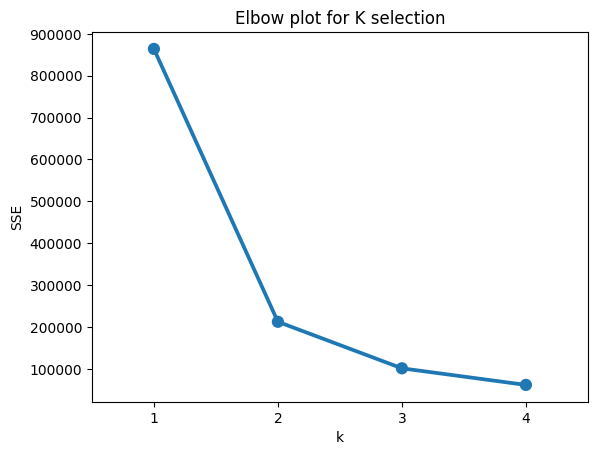

In [33]:
sse = {}

for k in range(1, 5):
  kmeans = KMeans(n_clusters=k, random_state=0).fit(test2_normalized)
  sse[k] = kmeans.inertia_

plt.title('Elbow plot for K selection')
plt.xlabel('k')
plt.ylabel('SSE')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

In [34]:
kn = kneed.KneeLocator(
    x=list(sse.keys()), 
    y=list(sse.values()), 
    curve='convex', 
    direction='decreasing', S=0.0)

In [35]:
k = kn.knee
kmeans_best = KMeans(n_clusters=k, random_state=0).fit(test2_normalized)

In [36]:
df_copy['cluster'] = kmeans_best.labels_

In [37]:
df_copy

,Period start,Leq,Leq_filtered,Leq_norm,cluster
0,2016-03-02 00:00:00.000,47.9,47.176917,-0.763220,0
1,2016-03-02 00:00:00.500,47.5,47.437145,-0.731462,0
2,2016-03-02 00:00:01.000,47.5,47.707476,-0.698471,0
3,2016-03-02 00:00:01.500,47.6,47.988073,-0.664227,0
4,2016-03-02 00:00:02.000,47.7,48.279089,-0.628711,0
...,...,...,...,...,...
864000,2016-03-06 23:59:58.000,47.2,45.636562,-0.951204,0
864001,2016-03-06 23:59:58.500,46.9,45.651567,-0.949373,0
864002,2016-03-06 23:59:59.000,46.8,45.664967,-0.947738,0
864003,2016-03-06 23:59:59.500,47.8,45.676710,-0.946305,0


In [38]:
clusters = np.unique(kmeans_best.labels_)

In [39]:
avg_cluster = [df_copy[df_copy['cluster'] == i]['Leq_filtered'].mean() for i in range(kn.knee)]
avg_cluster

[50.32622156050893, 69.73897539542621]

In [40]:
max_cluster = np.array(avg_cluster).argmax()
max_cluster

1

## Peak Extraction

In [39]:
peak_count = len(df_copy[df_copy['cluster'] == max_cluster])
unix_time = np.array(df_copy['Period start'])
time_on_max_clusters = np.array(df_copy[df_copy['cluster'] == max_cluster].index)
print("Peak count: %d" % peak_count)

Peak count: 85077


In [40]:
X = time_on_max_clusters.reshape(-1,1)

### DBSCAN

In [41]:
df_dbscan = df_clean.copy()

In [42]:
dbscan = DBSCAN(eps=150, min_samples=10).fit(X)

In [43]:
print(np.unique(dbscan.labels_))

[ -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160
 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178
 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196
 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214
 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232
 233 234 235 236 237 238 239 240 241 242 243 244 24

In [44]:
df_dbscan = df_dbscan.iloc[time_on_max_clusters]
df_dbscan['peak group'] = dbscan.labels_

In [45]:
df_dbscan = df_dbscan[df_dbscan['peak group'] != -1]
df_dbscan

,Period start,Leq,Leq_filtered,peak group
1842,2019-03-20 00:15:21.000,57.9,55.113372,0
1843,2019-03-20 00:15:21.500,57.9,55.234170,0
1844,2019-03-20 00:15:22.000,57.8,55.346514,0
1845,2019-03-20 00:15:22.500,58.1,55.450055,0
1846,2019-03-20 00:15:23.000,57.7,55.544492,0
...,...,...,...,...
1033598,2019-03-25 23:33:16.500,53.2,59.003034,424
1033599,2019-03-25 23:33:17.000,52.3,58.121778,424
1033600,2019-03-25 23:33:17.500,51.6,57.252584,424
1033601,2019-03-25 23:33:18.000,51.0,56.398862,424


In [46]:
n = len(np.unique(dbscan.labels_))
dbscan_labels = df_dbscan['peak group'].unique()

In [47]:
df2 = df_dbscan['peak group']

In [48]:
# plt.figure(figsize=(16,4))
# plt.plot(df_merge['Period start'], df_merge['Leq'])

# for c in dbscan_labels:
#     cond = df_merge[df_merge['peak group'] == c]
#     plt.plot(cond['Period start'], cond['Leq'], "o")
# plt.show()

In [49]:
print("Clustered peak count: %d" % len(set(dbscan_labels)))

Clustered peak count: 425


### Equivalent Continuous Sound Presure Level

In [50]:
def computeL_eq_t(data):
    sum_pow = np.sum(np.power(10, data/10))
    x = 1/len(data) * sum_pow 
    return 10 * math.log(x,10)

def SoundAddition(data):
    x = np.sum(np.power(10, data/10))
    return 10 * math.log(x,10)

def computeSEL(data):
    return computeL_eq_t(data) + 10 * math.log((len(data)*100)/1000)

In [51]:
peak_median = [np.median(df_dbscan[df_dbscan['peak group'] == i].index) for i in range(n) if (len(df_dbscan[df_dbscan['peak group'] == i]) != 0)]

In [52]:
results = []

unix_time = np.array(df['Period start'])

for c in df_dbscan['peak group'].unique():
    c_data = df_dbscan[df_dbscan['peak group'] == c].index
    min_t, max_t = c_data.min(), c_data.max()
    peak_t = int(peak_median[c])

    in_which_hour = min_t//one_hr_result

    raw = np.array(df_dbscan[df_dbscan['peak group'] == c]['Leq'])
    Leq = computeL_eq_t(raw)
    LAE = computeSEL(raw)

    r = {"hours":in_which_hour, "start_time": unix_time[min_t], "end_time": unix_time[max_t], "peak_time": peak_t,
         "interval": unix_time[max_t]-unix_time[min_t], "median":peak_median[c], "Leq":Leq, "Lae":LAE}

    results.append(r)

df_result = pd.DataFrame(results)

In [53]:
df_result

,hours,start_time,end_time,peak_time,interval,median,Leq,Lae
0,0,2019-03-20 00:15:21.000,2019-03-20 00:15:35.500,1856,0 days 00:00:14.500000,1856.5,56.476824,67.462947
1,1,2019-03-20 01:33:34.500,2019-03-20 01:34:01.500,11256,0 days 00:00:27,11256.0,64.253356,81.300837
2,1,2019-03-20 01:35:18.000,2019-03-20 01:35:43.500,11461,0 days 00:00:25.500000,11461.5,65.266343,81.752930
3,5,2019-03-20 05:55:04.500,2019-03-20 05:55:26.000,42630,0 days 00:00:21.500000,42630.5,55.960974,70.777019
4,6,2019-03-20 06:01:52.000,2019-03-20 06:02:59.000,43479,0 days 00:01:07,43479.5,71.360994,95.520132
...,...,...,...,...,...,...,...,...
420,141,2019-03-25 21:06:41.000,2019-03-25 21:07:14.000,1016040,0 days 00:00:33,1016040.0,76.398686,95.419761
421,141,2019-03-25 21:39:43.500,2019-03-25 21:40:12.000,1020000,0 days 00:00:28.500000,1020000.5,74.954199,92.532778
422,141,2019-03-25 21:46:45.500,2019-03-25 21:47:17.000,1020847,0 days 00:00:31.500000,1020847.5,74.270783,92.833763
423,142,2019-03-25 22:45:34.500,2019-03-25 22:46:02.500,1027902,0 days 00:00:28,1027902.0,76.053368,93.458030


In [54]:
df_result['interval'] = df_result['interval'] / np.timedelta64(1, 's')

In [55]:
df_result.head()

,hours,start_time,end_time,peak_time,interval,median,Leq,Lae
0,0,2019-03-20 00:15:21.000,2019-03-20 00:15:35.500,1856,14.5,1856.5,56.476824,67.462947
1,1,2019-03-20 01:33:34.500,2019-03-20 01:34:01.500,11256,27.0,11256.0,64.253356,81.300837
2,1,2019-03-20 01:35:18.000,2019-03-20 01:35:43.500,11461,25.5,11461.5,65.266343,81.752930
3,5,2019-03-20 05:55:04.500,2019-03-20 05:55:26.000,42630,21.5,42630.5,55.960974,70.777019
4,6,2019-03-20 06:01:52.000,2019-03-20 06:02:59.000,43479,67.0,43479.5,71.360994,95.520132


In [56]:
max(df_result['interval']), min(df_result['interval'])

(2249.5, 4.5)

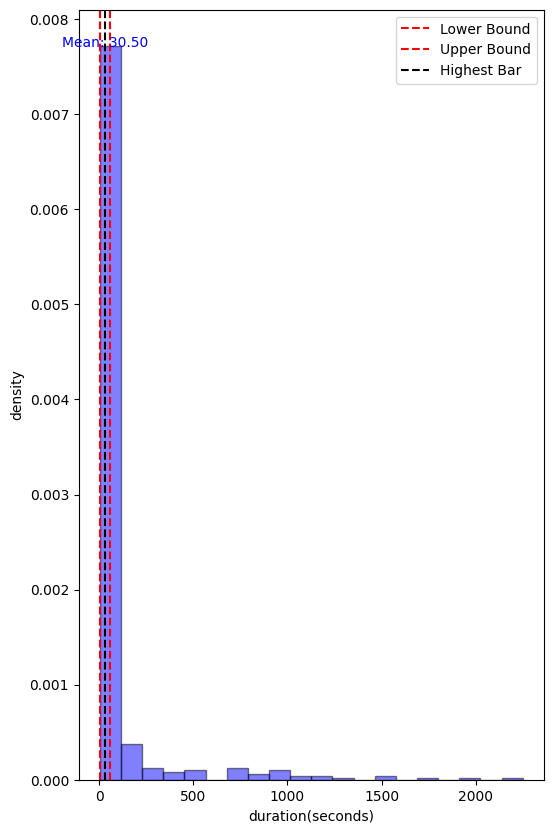

In [57]:
data = df_result['interval']

plt.figure(figsize=(6,10))
# Calculate IQR
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

# Calculate upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
if lower_bound < 0:
    lower_bound = 0

upper_bound = Q3 + 1.5 * IQR

# Create the histogram with density probability and blue color
bin_counts, bin_edges, _ = plt.hist(data, bins=20, density=True, color='blue', alpha=0.5, edgecolor='black')

# Add IQR boundaries
plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')

# Find the bin with the highest count
highest_bin_index = np.argmax(bin_counts)
highest_bin_value = bin_edges[highest_bin_index]

# Calculate the mean
mean_value = np.median(data) # 

# Add a line at the highest bar
plt.axvline(mean_value, color='black', linestyle='--', label='Highest Bar')

# Display the mean value at the highest bar
plt.text(mean_value, max(bin_counts), f'Mean: {mean_value:.2f}', color='blue', ha='center')

# Set x-axis tick values and labels
# plt.xticks([0, 50, 100, 150, 200])

# Show the legend
plt.legend()

# giving X and Y labels
plt.xlabel("duration(seconds)")
plt.ylabel("density")

# Display the plot
plt.show()

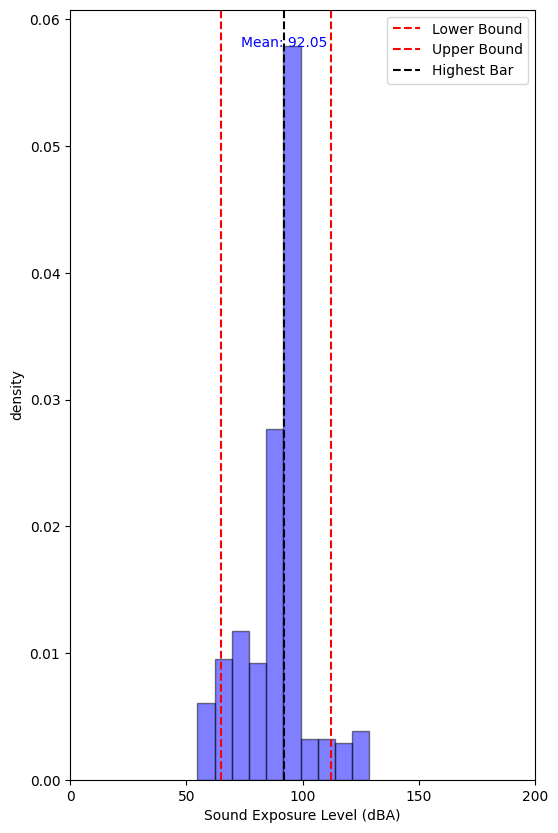

In [58]:
sound_info = df_result['Lae']

plt.figure(figsize=(6,10))
# Calculate IQR
Q1 = np.percentile(sound_info, 25)
Q3 = np.percentile(sound_info, 75)
IQR = Q3 - Q1

# Calculate upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create the histogram with density probability and blue color
bin_counts, bin_edges, _ = plt.hist(sound_info, bins=10, density=True, color='blue', alpha=0.5, edgecolor='black')

# Add IQR boundaries
plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')

highest_bin_index = np.argmax(bin_counts)
highest_bin_value = bin_edges[highest_bin_index]
mean_value = np.median(sound_info)

plt.axvline(mean_value, color='black', linestyle='--', label='Highest Bar')
plt.text(mean_value, max(bin_counts), f'Mean: {mean_value:.2f}', color='blue', ha='center')
plt.xticks([0, 50, 100, 150, 200])

plt.legend()
plt.xlabel("Sound Exposure Level (dBA)")
plt.ylabel("density")
plt.show()

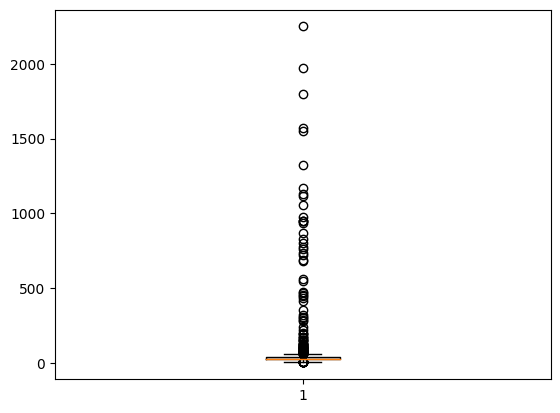

In [59]:
plt.boxplot(df_result['interval'])
plt.show()

In [60]:
Q1 = np.percentile(df_result['interval'], 25)
Q3 = np.percentile(df_result['interval'], 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_result_cleaned = df_result[~((df_result['interval'] < lower_bound) | (df_result['interval'] > upper_bound))]
df_result_cleaned.head()

,hours,start_time,end_time,peak_time,interval,median,Leq,Lae
0,0,2019-03-20 00:15:21.000,2019-03-20 00:15:35.500,1856,14.5,1856.5,56.476824,67.462947
1,1,2019-03-20 01:33:34.500,2019-03-20 01:34:01.500,11256,27.0,11256.0,64.253356,81.300837
2,1,2019-03-20 01:35:18.000,2019-03-20 01:35:43.500,11461,25.5,11461.5,65.266343,81.752930
3,5,2019-03-20 05:55:04.500,2019-03-20 05:55:26.000,42630,21.5,42630.5,55.960974,70.777019
9,6,2019-03-20 06:53:19.000,2019-03-20 06:53:47.000,49626,28.0,49626.0,61.870015,79.274676


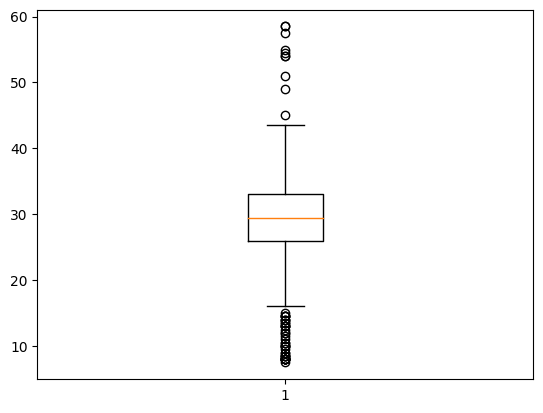

In [61]:
plt.boxplot(df_result_cleaned['interval'])
plt.show()

In [62]:
# df_result_cleaned.to_csv("../sound_proj/output.csv",index=False)

In [63]:
for i in range(len(df)//one_hr_result):
    data = df_result_cleaned[df_result_cleaned['hours'] == i+1]
    Lae_in_this_hour = np.array(data['Lae'])
    Leq_in_this_hour = np.array(data['Leq'])

    if(len(Lae_in_this_hour) == 0 and len(Leq_in_this_hour) == 0):
        print("Hour#%d no aircraft."% (i+1))
    else:
        Leq = SoundAddition(Leq_in_this_hour)
        Lae = SoundAddition(Lae_in_this_hour)
        
        print ("Hour#%d has %d aircraft(s) and sum of Leq of those aircraft(s) is %f and Lae is %f." % ((i+1), len(data), Leq, Lae))

    # aircraft_info.append({'start_time':time_start, 'end_time':time_end, 'aircrafts':len([df_result_cleaned['hours'] == i])})

    print()

Hour#1 has 2 aircraft(s) and sum of Leq of those aircraft(s) is 67.799618 and Lae is 84.543063.

Hour#2 no aircraft.

Hour#3 no aircraft.

Hour#4 no aircraft.

Hour#5 has 1 aircraft(s) and sum of Leq of those aircraft(s) is 55.960974 and Lae is 70.777019.

Hour#6 has 1 aircraft(s) and sum of Leq of those aircraft(s) is 61.870015 and Lae is 79.274676.

Hour#7 has 3 aircraft(s) and sum of Leq of those aircraft(s) is 76.540484 and Lae is 95.187801.

Hour#8 has 4 aircraft(s) and sum of Leq of those aircraft(s) is 79.432892 and Lae is 100.600144.

Hour#9 has 4 aircraft(s) and sum of Leq of those aircraft(s) is 74.144327 and Lae is 92.858573.

Hour#10 has 4 aircraft(s) and sum of Leq of those aircraft(s) is 79.326823 and Lae is 98.744297.

Hour#11 has 3 aircraft(s) and sum of Leq of those aircraft(s) is 75.381970 and Lae is 90.338150.

Hour#12 has 2 aircraft(s) and sum of Leq of those aircraft(s) is 76.166123 and Lae is 94.981328.

Hour#13 has 1 aircraft(s) and sum of Leq of those aircraft(s